# Probability for Statistics

Probability is the **language of uncertainty**, and it is the foundation of statistics: statistics uses data to *infer* things, and probability tells us how reliable those inferences are.

**Contents**
1. Setup
2. Basic concepts: experiment, sample space, event
3. Definition of probability & the axioms
4. Simulation: empirical vs theoretical probability
5. Counting: permutations & combinations
6. Rules of probability: complement, addition, multiplication
7. Conditional probability & independence
8. Law of Total Probability & Bayes' theorem
9. Random variables: discrete & continuous, PMF / PDF / CDF
10. Expected value, variance
11. Important discrete distributions: Bernoulli, Binomial, Geometric, Poisson
12. Important continuous distributions: Uniform, Normal, Exponential
13. Normal distribution, Z-scores & the standard normal
14. Law of Large Numbers
15. Central Limit Theorem
16. Joint distributions, covariance & correlation
17. Summary cheat-sheet & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, perm, factorial
import itertools

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(42)

## 2. Basic Concepts

| Term | Meaning | Example (rolling a die) |
|---|---|---|
| **Experiment** | A process with an uncertain outcome | Roll a die |
| **Outcome** | One possible result | 4 |
| **Sample space (S)** | Set of *all* outcomes | {1,2,3,4,5,6} |
| **Event** | A subset of the sample space | "even number" = {2,4,6} |
| **Simple event** | An event with one outcome | {3} |

Events can be combined with set operations:
* **A ∪ B** (union): A *or* B (or both) happens
* **A ∩ B** (intersection): A *and* B both happen
* **Aᶜ** (complement): A does *not* happen
* **Mutually exclusive (disjoint)**: A ∩ B = ∅ (can't happen together)

In [2]:
S = {1, 2, 3, 4, 5, 6}          # sample space
A = {2, 4, 6}                   # even
B = {4, 5, 6}                   # greater than 3

print("A ∪ B =", A | B)
print("A ∩ B =", A & B)
print("Aᶜ    =", S - A)
print("A and {1,3,5} mutually exclusive?", A & {1, 3, 5} == set())

A ∪ B = {2, 4, 5, 6}
A ∩ B = {4, 6}
Aᶜ    = {1, 3, 5}
A and {1,3,5} mutually exclusive? True


## 3. Definition of Probability & the Axioms

For **equally likely outcomes**, the classical definition is:

$$P(A) = \frac{\text{number of outcomes in } A}{\text{number of outcomes in } S}$$

**Kolmogorov's axioms** (the rules every probability must obey):
1. $0 \le P(A) \le 1$
2. $P(S) = 1$ (something must happen)
3. If A and B are mutually exclusive, $P(A \cup B) = P(A) + P(B)$

In [3]:
def prob(event, space):
    return len(event) / len(space)

print("P(even)         =", prob(A, S))
print("P(greater than 3) =", prob(B, S))
print("P(S)            =", prob(S, S))
print("P(impossible)   =", prob(set(), S))

P(even)         = 0.5
P(greater than 3) = 0.5
P(S)            = 1.0
P(impossible)   = 0.0


## 4. Empirical vs Theoretical Probability

* **Theoretical**: computed from reasoning (P(heads) = 0.5).
* **Empirical (relative frequency)**: fraction observed in repeated experiments.

As trials increase, empirical → theoretical. This is the **Law of Large Numbers** (Section 14).

In [4]:
rolls = rng.integers(1, 7, size=100_000)          # simulate 100,000 die rolls
print("Simulated P(even):", np.mean(rolls % 2 == 0), " | Theoretical: 0.5")
print("Simulated P(6)   :", np.mean(rolls == 6),     " | Theoretical:", round(1/6, 4))

Simulated P(even): 0.49962  | Theoretical: 0.5
Simulated P(6)   : 0.16586  | Theoretical: 0.1667


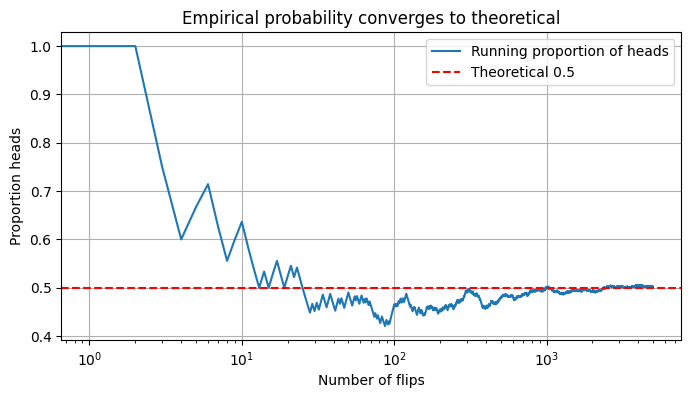

In [5]:
# Convergence plot
flips = rng.integers(0, 2, size=5000)                       # 1 = heads
running = np.cumsum(flips) / np.arange(1, len(flips) + 1)

plt.plot(running, label="Running proportion of heads")
plt.axhline(0.5, color="red", ls="--", label="Theoretical 0.5")
plt.xscale("log"); plt.xlabel("Number of flips"); plt.ylabel("Proportion heads")
plt.title("Empirical probability converges to theoretical"); plt.legend(); plt.show()

### Two dice: a bigger sample space

With two dice there are 6 × 6 = 36 equally likely outcomes. Let's list them and compute probabilities of sums.

Total outcomes: 36
2     0.0278
3     0.0556
4     0.0833
5     0.1111
6     0.1389
7     0.1667
8     0.1389
9     0.1111
10    0.0833
11    0.0556
12    0.0278


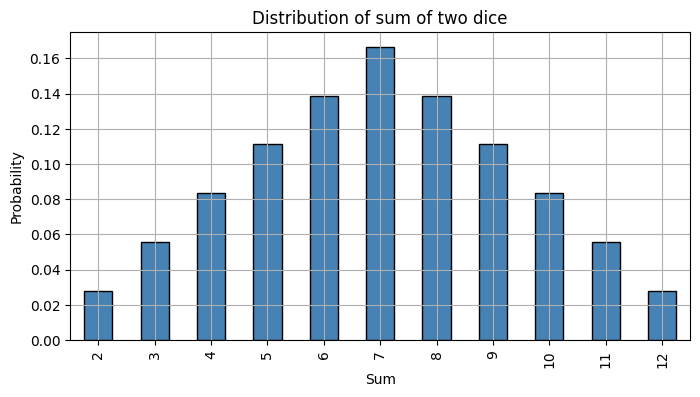

P(sum = 7)  = 0.1667 = 6/36
P(sum >= 10) = 0.1667


In [6]:
two_dice = list(itertools.product(range(1, 7), repeat=2))
print("Total outcomes:", len(two_dice))

sums = pd.Series([a + b for a, b in two_dice])
dist = (sums.value_counts().sort_index() / len(two_dice))
print(dist.round(4).to_string())

dist.plot(kind="bar", color="steelblue", edgecolor="black", title="Distribution of sum of two dice")
plt.xlabel("Sum"); plt.ylabel("Probability"); plt.show()

print("P(sum = 7)  =", dist[7].round(4), "= 6/36")
print("P(sum >= 10) =", dist[dist.index >= 10].sum().round(4))

## 5. Counting: Permutations & Combinations

To compute classical probabilities we often need to **count** outcomes.

* **Multiplication principle**: if one step has *m* ways and another has *n* ways, together there are *m × n* ways.
* **Factorial**: $n! = n \times (n-1) \times \dots \times 1$
* **Permutations** (order matters): $P(n,r) = \dfrac{n!}{(n-r)!}$
* **Combinations** (order doesn't matter): $C(n,r) = \dbinom{n}{r} = \dfrac{n!}{r!\,(n-r)!}$

In [7]:
print("5! =", factorial(5))
print("Ways to arrange 3 of 5 books on a shelf (order matters): P(5,3) =", perm(5, 3))
print("Ways to choose 3 of 5 books (order doesn't matter):       C(5,3) =", comb(5, 3))

5! = 120
Ways to arrange 3 of 5 books on a shelf (order matters): P(5,3) = 60
Ways to choose 3 of 5 books (order doesn't matter):       C(5,3) = 10


In [8]:
# Example: probability of getting exactly 2 aces in a 5-card poker hand
# Ways to choose 2 aces from 4  * ways to choose 3 non-aces from 48  /  all 5-card hands
p = comb(4, 2) * comb(48, 3) / comb(52, 5)
print("P(exactly 2 aces in 5 cards) =", round(p, 5))

# Example: birthday problem  -> P(at least 2 of n people share a birthday)
def birthday(n):
    p_all_diff = np.prod([(365 - k) / 365 for k in range(n)])
    return 1 - p_all_diff

for n in (10, 23, 30, 50, 70):
    print(f"n = {n:2d}:  P(shared birthday) = {birthday(n):.3f}")

P(exactly 2 aces in 5 cards) = 0.03993
n = 10:  P(shared birthday) = 0.117
n = 23:  P(shared birthday) = 0.507
n = 30:  P(shared birthday) = 0.706
n = 50:  P(shared birthday) = 0.970
n = 70:  P(shared birthday) = 0.999


Surprise: with only **23** people there's already a >50% chance two share a birthday. Human intuition about probability is often poor, which is why we compute.

## 6. Rules of Probability

### 6.1 Complement rule
$$P(A^c) = 1 - P(A)$$
Useful for "at least one" problems.

### 6.2 Addition rule
$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$
(subtract the overlap so it isn't counted twice). If A, B are mutually exclusive, the last term is 0.

### 6.3 Multiplication rule
$$P(A \cap B) = P(A)\,P(B \mid A)$$
If A, B are **independent**: $P(A \cap B) = P(A)\,P(B)$.

In [9]:
# Card example: P(King OR Heart) in a 52-card deck
p_king, p_heart, p_king_heart = 4/52, 13/52, 1/52
print("P(King or Heart) =", round(p_king + p_heart - p_king_heart, 4), "= 16/52")

# Complement: P(at least one six in 4 rolls of a die)
p_none = (5/6) ** 4
print("P(at least one 6 in 4 rolls) =", round(1 - p_none, 4))

# Multiplication (independent): P(two heads in a row)
print("P(HH) =", 0.5 * 0.5)

# Multiplication (dependent): drawing 2 aces WITHOUT replacement
print("P(two aces, no replacement) =", round((4/52) * (3/51), 5))

P(King or Heart) = 0.3077 = 16/52
P(at least one 6 in 4 rolls) = 0.5177
P(HH) = 0.25
P(two aces, no replacement) = 0.00452


## 7. Conditional Probability & Independence

**Conditional probability** = probability of A *given that B has happened*:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \qquad P(B) > 0$$

Knowing B **shrinks the sample space** to B.

**Independence**: A and B are independent if knowing one tells you nothing about the other:

$$P(A \mid B) = P(A) \iff P(A \cap B) = P(A)P(B)$$

⚠️ *Independent* ≠ *mutually exclusive*. Mutually exclusive events with non-zero probability are actually **dependent** (if one happens, the other definitely doesn't).

In [10]:
# Data: 200 people surveyed - gender vs. whether they like coffee
table = pd.DataFrame(
    {"Male": [60, 40], "Female": [30, 70]},
    index=["Likes Coffee", "Doesn't like Coffee"]
)
table["Total"] = table.sum(axis=1)
table.loc["Total"] = table.sum()
print(table, "\n")

N = table.loc["Total", "Total"]
p_coffee        = table.loc["Likes Coffee", "Total"] / N
p_male          = table.loc["Total", "Male"] / N
p_coffee_and_m  = table.loc["Likes Coffee", "Male"] / N
p_coffee_given_male = p_coffee_and_m / p_male

print(f"P(Coffee)          = {p_coffee:.3f}")
print(f"P(Male)            = {p_male:.3f}")
print(f"P(Coffee ∩ Male)   = {p_coffee_and_m:.3f}")
print(f"P(Coffee | Male)   = {p_coffee_given_male:.3f}")
print("Independent? P(Coffee|Male) == P(Coffee)?", np.isclose(p_coffee_given_male, p_coffee))

                     Male  Female  Total
Likes Coffee           60      30     90
Doesn't like Coffee    40      70    110
Total                 100     100    200 

P(Coffee)          = 0.450
P(Male)            = 0.500
P(Coffee ∩ Male)   = 0.300
P(Coffee | Male)   = 0.600
Independent? P(Coffee|Male) == P(Coffee)? False


In [11]:
# Check independence by simulation: two separate die rolls
d1 = rng.integers(1, 7, 200_000)
d2 = rng.integers(1, 7, 200_000)
A_ev = d1 == 6
B_ev = d2 == 6
print("P(A)P(B) =", round(A_ev.mean() * B_ev.mean(), 4))
print("P(A∩B)   =", round((A_ev & B_ev).mean(), 4), "  <- about equal => independent")

P(A)P(B) = 0.0278
P(A∩B)   = 0.0275   <- about equal => independent


## 8. Law of Total Probability & Bayes' Theorem

### Law of Total Probability
If $B_1, B_2, \dots, B_k$ partition the sample space (disjoint, cover everything):

$$P(A) = \sum_i P(A \mid B_i)\,P(B_i)$$

### Bayes' Theorem
Flips the conditioning: from $P(A\mid B)$ to $P(B\mid A)$.

$$P(B \mid A) = \frac{P(A \mid B)\,P(B)}{P(A)}$$

Terminology: **prior** P(B) → (observe evidence A) → **posterior** P(B|A).

### Classic example: medical test
* Disease prevalence: 1% (prior)
* Test **sensitivity** P(+ | disease) = 99%
* Test **false-positive rate** P(+ | no disease) = 5%

If you test positive, what's the chance you actually have the disease?

In [12]:
p_d        = 0.01          # prior
p_pos_d    = 0.99          # sensitivity
p_pos_nd   = 0.05          # false positive rate

# Law of total probability for P(+)
p_pos = p_pos_d * p_d + p_pos_nd * (1 - p_d)

# Bayes
p_d_pos = p_pos_d * p_d / p_pos

print(f"P(positive)               = {p_pos:.4f}")
print(f"P(disease | positive)     = {p_d_pos:.4f}  ({p_d_pos*100:.1f}%)")

P(positive)               = 0.0594
P(disease | positive)     = 0.1667  (16.7%)


Only about **17%**, not 99%! Because the disease is rare, most positives are false positives. Let's see it with a population of 10,000 people.

Sick: 100 -> true positives: 99
Healthy: 9900 -> false positives: 495
Of 594 positive tests, only 99 are truly sick = 16.7%


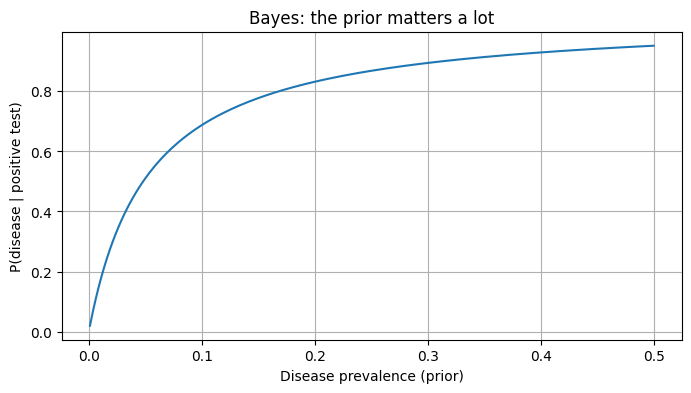

In [13]:
pop = 10_000
sick = pop * p_d
healthy = pop - sick
true_pos = sick * p_pos_d
false_pos = healthy * p_pos_nd

print(f"Sick: {sick:.0f} -> true positives: {true_pos:.0f}")
print(f"Healthy: {healthy:.0f} -> false positives: {false_pos:.0f}")
print(f"Of {true_pos + false_pos:.0f} positive tests, only {true_pos:.0f} are truly sick = {true_pos/(true_pos+false_pos):.1%}")

# How the posterior changes with prevalence
prev = np.linspace(0.001, 0.5, 200)
post = p_pos_d * prev / (p_pos_d * prev + p_pos_nd * (1 - prev))
plt.plot(prev, post)
plt.xlabel("Disease prevalence (prior)"); plt.ylabel("P(disease | positive test)")
plt.title("Bayes: the prior matters a lot"); plt.show()

### Bayes with a sequential update
Bayesian thinking: today's posterior becomes tomorrow's prior. Suppose a person tests positive **twice** (independent tests).

In [14]:
def update(prior, sens=0.99, fpr=0.05):
    num = sens * prior
    return num / (num + fpr * (1 - prior))

p = 0.01
for i in range(1, 4):
    p = update(p)
    print(f"After positive test #{i}: P(disease) = {p:.4f}")

After positive test #1: P(disease) = 0.1667
After positive test #2: P(disease) = 0.7984
After positive test #3: P(disease) = 0.9874


## 9. Random Variables

A **random variable (RV)** assigns a **number** to each outcome of an experiment. Written with capital letters (X, Y).

* **Discrete RV**: takes countable values (number of heads, defects, calls).
  Described by a **PMF** (probability mass function) $p(x) = P(X = x)$.
* **Continuous RV**: takes any value in an interval (height, time, temperature).
  Described by a **PDF** (probability density function) $f(x)$. Probabilities are **areas under the curve**: $P(a \le X \le b) = \int_a^b f(x)\,dx$. For a continuous RV, $P(X = x) = 0$ for any single point.
* **CDF** (cumulative distribution function), for both types: $F(x) = P(X \le x)$.

Requirements: PMF must be ≥ 0 and sum to 1. PDF must be ≥ 0 and integrate to 1.

   PMF  P(X=x)  CDF  P(X<=x)
0        0.125         0.125
1        0.375         0.500
2        0.375         0.875
3        0.125         1.000
Sum of PMF: 1.0


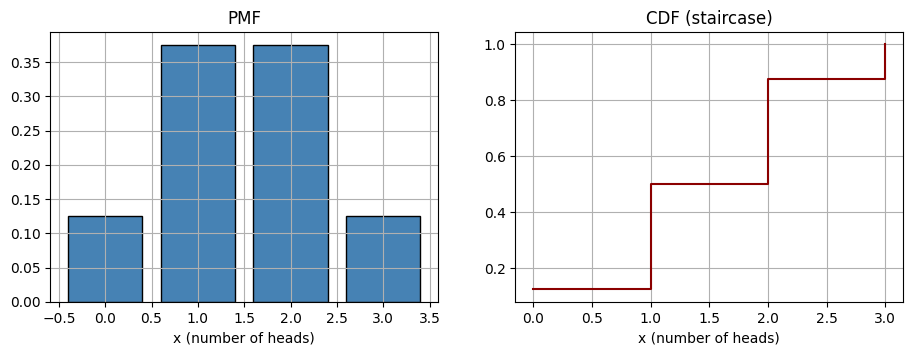

In [15]:
# Discrete: X = number of heads in 3 fair coin flips
outcomes = list(itertools.product("HT", repeat=3))
X = pd.Series([o.count("H") for o in outcomes])
pmf = X.value_counts(normalize=True).sort_index()
cdf = pmf.cumsum()

print(pd.DataFrame({"PMF  P(X=x)": pmf, "CDF  P(X<=x)": cdf}).round(3))
print("Sum of PMF:", pmf.sum())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(pmf.index, pmf.values, color="steelblue", edgecolor="black"); ax[0].set_title("PMF")
ax[1].step(cdf.index, cdf.values, where="post", color="darkred");      ax[1].set_title("CDF (staircase)")
for a in ax: a.set_xlabel("x (number of heads)")
plt.show()

## 10. Expected Value & Variance of a Random Variable

The **expected value** (mean, μ) is the long-run average, the *probability-weighted* average of all outcomes.

$$E[X] = \sum x\,p(x) \quad(\text{discrete}) \qquad E[X] = \int x\,f(x)\,dx \quad(\text{continuous})$$

**Variance**:
$$\text{Var}(X) = E[(X-\mu)^2] = E[X^2] - (E[X])^2, \qquad \sigma = \sqrt{\text{Var}(X)}$$

**Useful properties** (a, b constants):
* $E[aX + b] = aE[X] + b$
* $\text{Var}(aX + b) = a^2\,\text{Var}(X)$
* $E[X+Y] = E[X] + E[Y]$ (always)
* $\text{Var}(X+Y) = \text{Var}(X)+\text{Var}(Y)$ **only if X, Y independent**

In [16]:
# Fair die
x = np.arange(1, 7)
p = np.full(6, 1/6)

E  = np.sum(x * p)
E2 = np.sum(x**2 * p)
var = E2 - E**2
print(f"E[X] = {E:.3f}, E[X^2] = {E2:.3f}, Var(X) = {var:.3f}, SD = {np.sqrt(var):.3f}")

# Fair-game example: lottery ticket costs Rs 10, 1 in 1000 chance of winning Rs 5000
gain = np.array([5000 - 10, -10])
pr   = np.array([1/1000, 999/1000])
print("\nExpected profit per ticket:", np.sum(gain * pr), " -> negative => not a fair game")

E[X] = 3.500, E[X^2] = 15.167, Var(X) = 2.917, SD = 1.708

Expected profit per ticket: -5.0  -> negative => not a fair game


In [17]:
# Verify properties via simulation
X = rng.integers(1, 7, 500_000)
print("E[2X+3]     theory:", 2*E + 3,        " sim:", round((2*X + 3).mean(), 3))
print("Var(2X+3)   theory:", 4*var,          " sim:", round((2*X + 3).var(), 3))

Y = rng.integers(1, 7, 500_000)            # independent die
print("Var(X+Y)    theory:", 2*var,          " sim:", round((X + Y).var(), 3), " (independent -> variances add)")

E[2X+3]     theory: 10.0  sim: 9.992
Var(2X+3)   theory: 11.666666666666664  sim: 11.648
Var(X+Y)    theory: 5.833333333333332  sim: 5.815  (independent -> variances add)


## 11. Important Discrete Distributions

### 11.1 Bernoulli(p)
One trial with two outcomes: success (1) with prob *p*, failure (0) with prob *1−p*.
$E[X]=p,\; \text{Var}(X)=p(1-p)$

In [18]:
p = 0.3
bern = stats.bernoulli(p)
print("P(X=1) =", bern.pmf(1), " P(X=0) =", bern.pmf(0))
print("Mean =", bern.mean(), " Var =", bern.var())

P(X=1) = 0.3  P(X=0) = 0.7000000000000002
Mean = 0.3  Var = 0.21


### 11.2 Binomial(n, p)
Number of successes in **n independent** Bernoulli(p) trials.

$$P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}, \qquad E[X]=np,\; \text{Var}(X)=np(1-p)$$

Conditions (BINS): **B**inary outcomes, **I**ndependent trials, fixed **N**, constant **S**uccess probability.

Example: A factory has a 5% defect rate. In a batch of 20 items...

In [19]:
n, p = 20, 0.05
binom = stats.binom(n, p)

print("P(exactly 2 defects)     =", round(binom.pmf(2), 4))
print("P(at most 2 defects)     =", round(binom.cdf(2), 4))
print("P(at least 1 defect)     =", round(1 - binom.pmf(0), 4), "= 1 - P(0)")
print("P(more than 3 defects)   =", round(binom.sf(3), 4), "  (sf = 1 - cdf)")
print("Mean =", binom.mean(), " SD =", round(binom.std(), 3))

# Manual formula check
k = 2
print("Manual formula P(X=2):", round(comb(n, k) * p**k * (1-p)**(n-k), 4))

P(exactly 2 defects)     = 0.1887
P(at most 2 defects)     = 0.9245
P(at least 1 defect)     = 0.6415 = 1 - P(0)
P(more than 3 defects)   = 0.0159   (sf = 1 - cdf)
Mean = 1.0  SD = 0.975
Manual formula P(X=2): 0.1887


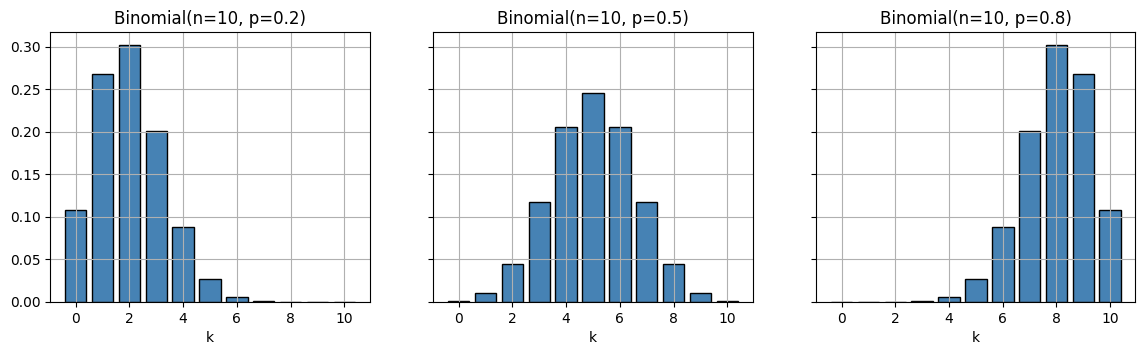

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (n_, p_) in zip(axes, [(10, 0.2), (10, 0.5), (10, 0.8)]):
    k = np.arange(0, n_ + 1)
    ax.bar(k, stats.binom.pmf(k, n_, p_), color="steelblue", edgecolor="black")
    ax.set_title(f"Binomial(n={n_}, p={p_})"); ax.set_xlabel("k")
plt.show()

### 11.3 Geometric(p)
Number of trials **until the first success**.

$$P(X=k) = (1-p)^{k-1}p, \quad k = 1,2,\dots \qquad E[X] = \frac{1}{p}$$

Example: rolling a die until you get a 6 (p = 1/6). On average it takes 6 rolls.

In [21]:
geo = stats.geom(1/6)
print("P(first 6 on 3rd roll) =", round(geo.pmf(3), 4))
print("P(need more than 10 rolls) =", round(geo.sf(10), 4))
print("Expected # of rolls =", geo.mean())

sim = rng.geometric(1/6, 100_000)
print("Simulated mean =", sim.mean().round(3))

P(first 6 on 3rd roll) = 0.1157
P(need more than 10 rolls) = 0.1615
Expected # of rolls = 6.0
Simulated mean = 6.016


### 11.4 Poisson(λ)
Number of events in a fixed interval of time/space when events occur **independently at a constant average rate λ**.

$$P(X=k) = \frac{e^{-\lambda}\lambda^k}{k!}, \qquad E[X]=\text{Var}(X)=\lambda$$

Examples: calls per hour, typos per page, accidents per day.

Example: a call centre receives on average 4 calls per minute.

P(exactly 6 calls)   = 0.1042
P(at most 2 calls)   = 0.2381
P(more than 8 calls) = 0.0214
Mean = Var = 4.0 4.0


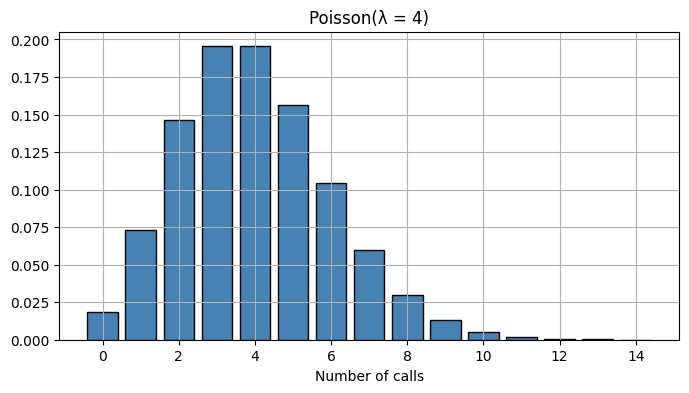

In [22]:
lam = 4
pois = stats.poisson(lam)
print("P(exactly 6 calls)   =", round(pois.pmf(6), 4))
print("P(at most 2 calls)   =", round(pois.cdf(2), 4))
print("P(more than 8 calls) =", round(pois.sf(8), 4))
print("Mean = Var =", pois.mean(), pois.var())

k = np.arange(0, 15)
plt.bar(k, pois.pmf(k), color="steelblue", edgecolor="black")
plt.title("Poisson(λ = 4)"); plt.xlabel("Number of calls"); plt.show()

**Link:** Binomial(n, p) with large *n* and small *p* is approximated by Poisson(λ = np).

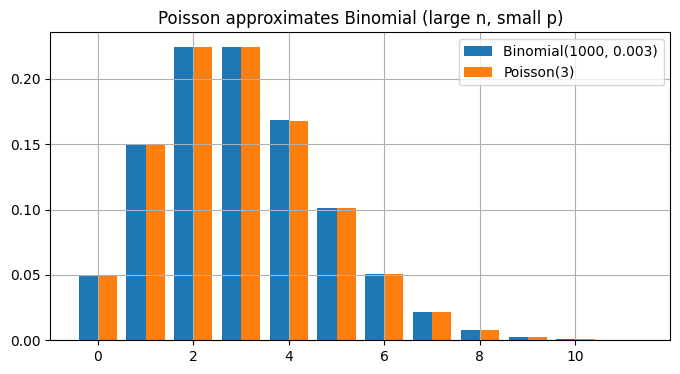

In [23]:
n, p = 1000, 0.003          # lambda = 3
k = np.arange(0, 12)
plt.bar(k - 0.2, stats.binom.pmf(k, n, p), width=0.4, label="Binomial(1000, 0.003)")
plt.bar(k + 0.2, stats.poisson.pmf(k, n*p), width=0.4, label="Poisson(3)")
plt.legend(); plt.title("Poisson approximates Binomial (large n, small p)"); plt.show()

## 12. Important Continuous Distributions

### 12.1 Uniform(a, b)
All values in [a, b] equally likely. PDF is flat: $f(x)=\frac{1}{b-a}$.
$E[X]=\frac{a+b}{2},\; \text{Var}(X)=\frac{(b-a)^2}{12}$

P(2 <= X <= 5) = 0.3 = 3/10
Mean = 5.0  Var = 8.333


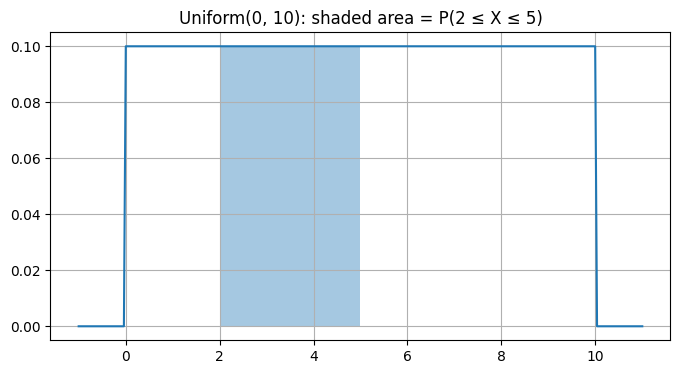

In [24]:
a, b = 0, 10
unif = stats.uniform(loc=a, scale=b - a)      # scipy uses loc, scale = width

print("P(2 <= X <= 5) =", round(unif.cdf(5) - unif.cdf(2), 3), "= 3/10")
print("Mean =", unif.mean(), " Var =", round(unif.var(), 3))

x = np.linspace(-1, 11, 300)
plt.plot(x, unif.pdf(x)); plt.fill_between(x, unif.pdf(x), where=(x >= 2) & (x <= 5), alpha=0.4)
plt.title("Uniform(0, 10): shaded area = P(2 ≤ X ≤ 5)"); plt.show()

### 12.2 Exponential(λ)
**Waiting time** until the next event in a Poisson process (rate λ).

$$f(x)=\lambda e^{-\lambda x},\; x \ge 0 \qquad E[X]=\frac1\lambda,\; \text{Var}(X)=\frac1{\lambda^2}$$

**Memoryless property:** $P(X > s+t \mid X > s) = P(X > t)$, so the past doesn't matter.

Example: buses arrive at a rate of 2 per hour. Time until the next bus?

Mean wait (hours) = 0.5
P(wait < 15 min)  = 0.3935
P(wait > 1 hour)  = 0.1353
P(X>1.5 | X>1) = 0.3679   P(X>0.5) = 0.3679


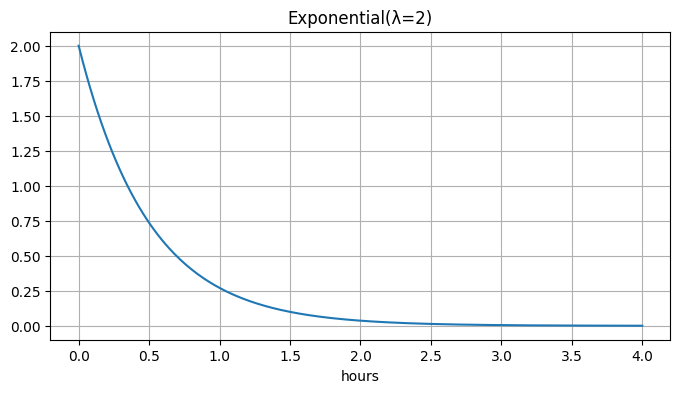

In [25]:
lam = 2                                  # per hour
expo = stats.expon(scale=1/lam)          # scipy uses scale = 1/lambda

print("Mean wait (hours) =", expo.mean())
print("P(wait < 15 min)  =", round(expo.cdf(0.25), 4))
print("P(wait > 1 hour)  =", round(expo.sf(1), 4))

# Memoryless check: P(X>1.5 | X>1) vs P(X>0.5)
print("P(X>1.5 | X>1) =", round(expo.sf(1.5) / expo.sf(1), 4), "  P(X>0.5) =", round(expo.sf(0.5), 4))

x = np.linspace(0, 4, 300)
plt.plot(x, expo.pdf(x)); plt.title("Exponential(λ=2)"); plt.xlabel("hours"); plt.show()

### 12.3 Normal (Gaussian) Distribution N(μ, σ²)
The famous **bell curve**. Determined by mean μ (center) and standard deviation σ (spread).

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Properties: symmetric, mean = median = mode, total area = 1, and the 68-95-99.7 rule.
It matters so much because of the **Central Limit Theorem** (Section 15).

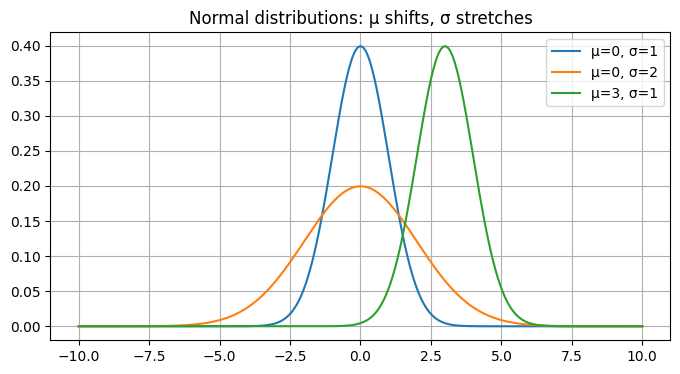

In [26]:
x = np.linspace(-10, 10, 500)
for mu, sd in [(0, 1), (0, 2), (3, 1)]:
    plt.plot(x, stats.norm.pdf(x, mu, sd), label=f"μ={mu}, σ={sd}")
plt.legend(); plt.title("Normal distributions: μ shifts, σ stretches"); plt.show()

## 13. Normal Distribution, Z-scores & the Standard Normal

Any normal X ~ N(μ, σ²) can be **standardised**:

$$Z = \frac{X-\mu}{\sigma} \sim N(0,1)$$

Z tells you how many standard deviations X is from the mean. Probabilities are then looked up on the **standard normal** (z-table); in code we use `norm.cdf`.

Example: exam scores ~ N(70, 10²).

In [27]:
mu, sd = 70, 10
X = stats.norm(mu, sd)

print("P(X < 85)        =", round(X.cdf(85), 4))
print("P(X > 90)        =", round(X.sf(90), 4))
print("P(60 < X < 80)   =", round(X.cdf(80) - X.cdf(60), 4), " (≈ 68% rule)")

# Via z-scores (equivalent)
z = (85 - mu) / sd
print(f"\nz for 85 = {z};  P(Z < {z}) = {stats.norm.cdf(z):.4f}")

# Inverse: what score is the 90th percentile? (ppf = percent point function)
print("90th percentile score =", round(X.ppf(0.90), 2))
print("Middle 95% of scores lie between", X.ppf(0.025).round(2), "and", X.ppf(0.975).round(2))

P(X < 85)        = 0.9332
P(X > 90)        = 0.0228
P(60 < X < 80)   = 0.6827  (≈ 68% rule)

z for 85 = 1.5;  P(Z < 1.5) = 0.9332
90th percentile score = 82.82
Middle 95% of scores lie between 50.4 and 89.6


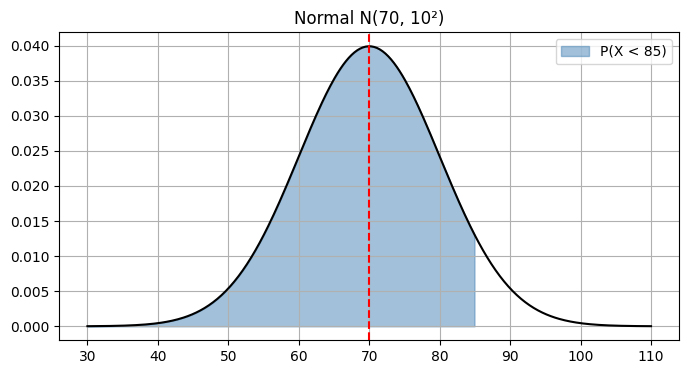

90% two-sided critical z = ±1.645
95% two-sided critical z = ±1.960
99% two-sided critical z = ±2.576


In [28]:
# Shade the probability P(X < 85)
x = np.linspace(30, 110, 400)
plt.plot(x, X.pdf(x), color="k")
plt.fill_between(x, X.pdf(x), where=x <= 85, color="steelblue", alpha=0.5, label="P(X < 85)")
plt.axvline(mu, color="r", ls="--"); plt.legend(); plt.title("Normal N(70, 10²)"); plt.show()

# Critical z-values used constantly in hypothesis testing / confidence intervals
for conf in (0.90, 0.95, 0.99):
    print(f"{conf:.0%} two-sided critical z = ±{stats.norm.ppf(1 - (1-conf)/2):.3f}")

## 14. Law of Large Numbers (LLN)

As the sample size *n* grows, the **sample mean** $\bar X_n$ converges to the true mean μ.

This is why casinos always win in the long run and why larger samples give more reliable estimates.

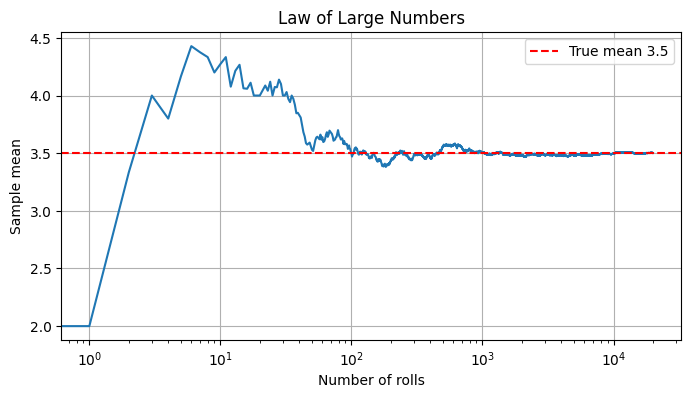

In [29]:
# Die rolls: true mean = 3.5
rolls = rng.integers(1, 7, 20_000)
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)

plt.plot(running_mean)
plt.axhline(3.5, color="red", ls="--", label="True mean 3.5")
plt.xscale("log"); plt.xlabel("Number of rolls"); plt.ylabel("Sample mean")
plt.title("Law of Large Numbers"); plt.legend(); plt.show()

## 15. Central Limit Theorem (CLT)

> For a sample of size *n* (large enough, typically n ≥ 30) from **any** population with mean μ and standard deviation σ, the distribution of the **sample mean** is approximately normal:
> $$\bar X \approx N\!\left(\mu,\ \frac{\sigma^2}{n}\right)$$
> The standard deviation of $\bar X$, called the **standard error**, is $\sigma/\sqrt{n}$.

This is arguably **the most important theorem in statistics**: it justifies confidence intervals and hypothesis tests even when the raw data isn't normal.

Let's test it on a strongly skewed population (exponential).

Population mean: 2.003  SD: 2.003


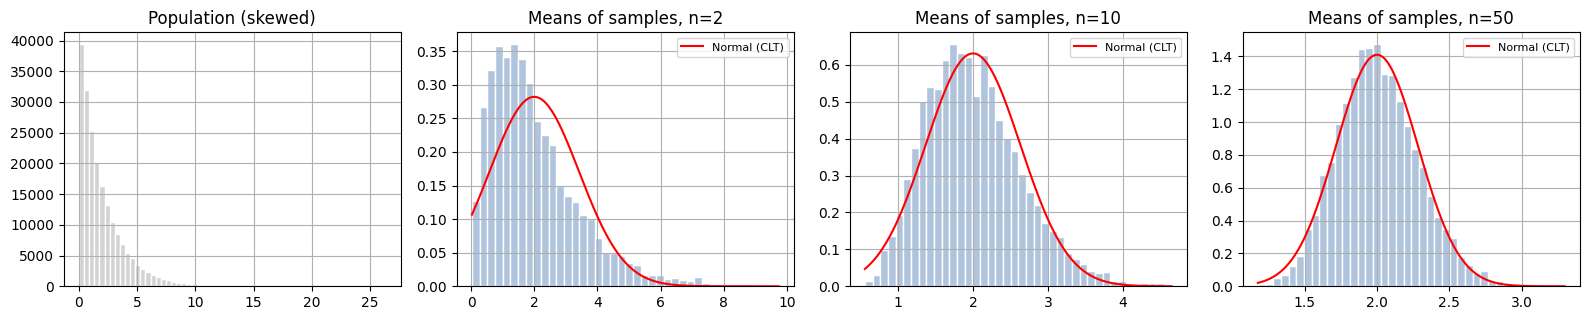

In [30]:
population = rng.exponential(scale=2, size=200_000)      # highly skewed, mean = 2, sd = 2
print("Population mean:", population.mean().round(3), " SD:", population.std().round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
axes[0].hist(population, bins=60, color="lightgray", edgecolor="white"); axes[0].set_title("Population (skewed)")

for ax, n in zip(axes[1:], [2, 10, 50]):
    sample_means = rng.choice(population, size=(5000, n)).mean(axis=1)
    ax.hist(sample_means, bins=40, density=True, color="lightsteelblue", edgecolor="white")
    xs = np.linspace(sample_means.min(), sample_means.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, 2, 2/np.sqrt(n)), "r-", label="Normal (CLT)")
    ax.set_title(f"Means of samples, n={n}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [31]:
# Standard error shrinks with sqrt(n)
for n in (5, 25, 100, 400):
    means = rng.choice(population, size=(4000, n)).mean(axis=1)
    print(f"n = {n:3d}:  SD of sample means = {means.std():.3f}   theory σ/√n = {2/np.sqrt(n):.3f}")

n =   5:  SD of sample means = 0.874   theory σ/√n = 0.894
n =  25:  SD of sample means = 0.401   theory σ/√n = 0.400
n = 100:  SD of sample means = 0.194   theory σ/√n = 0.200
n = 400:  SD of sample means = 0.101   theory σ/√n = 0.100


Note: to **halve** the standard error you need **4×** the sample size (because of the √n).

## 16. Joint Distributions, Covariance & Correlation

For two random variables X and Y:

* **Joint PMF** $p(x,y)=P(X=x, Y=y)$ describes them together.
* **Marginal**: sum over the other variable, $p_X(x)=\sum_y p(x,y)$.
* **Covariance**: $\text{Cov}(X,Y)=E[(X-\mu_X)(Y-\mu_Y)]$, the direction of linear co-movement.
* **Correlation**: $\rho = \dfrac{\text{Cov}(X,Y)}{\sigma_X\sigma_Y} \in [-1, 1]$, unit-free.
* Independent ⇒ covariance = 0, **but** zero covariance does **not** imply independence.
* General: $\text{Var}(X+Y)=\text{Var}(X)+\text{Var}(Y)+2\,\text{Cov}(X,Y)$

In [32]:
# Joint PMF as a table: X = 1,2,3   Y = 0,1
joint = pd.DataFrame(
    [[0.10, 0.20],
     [0.15, 0.15],
     [0.30, 0.10]],
    index=pd.Index([1, 2, 3], name="X"), columns=pd.Index([0, 1], name="Y")
)
print(joint, "\nTotal =", joint.values.sum(), "\n")

px = joint.sum(axis=1)      # marginal of X
py = joint.sum(axis=0)      # marginal of Y
print("Marginal X:\n", px.to_string(), "\n\nMarginal Y:\n", py.to_string(), "\n")

EX = (px.index * px).sum()
EY = (py.index * py).sum()
EXY = sum(x * y * joint.loc[x, y] for x in joint.index for y in joint.columns)
cov = EXY - EX * EY
sdx = np.sqrt(((px.index - EX) ** 2 * px).sum())
sdy = np.sqrt(((py.index - EY) ** 2 * py).sum())
print(f"E[X]={EX:.2f}, E[Y]={EY:.2f}, E[XY]={EXY:.2f}")
print(f"Cov(X,Y) = {cov:.3f},  Corr = {cov/(sdx*sdy):.3f}")

# Independent? joint == outer(px, py)?
print("Independent?", np.allclose(joint.values, np.outer(px, py)))

Y     0     1
X            
1  0.10  0.20
2  0.15  0.15
3  0.30  0.10 
Total = 1.0 

Marginal X:
 X
1    0.3
2    0.3
3    0.4 

Marginal Y:
 Y
0    0.55
1    0.45 

E[X]=2.10, E[Y]=0.45, E[XY]=0.80
Cov(X,Y) = -0.145,  Corr = -0.351
Independent? False


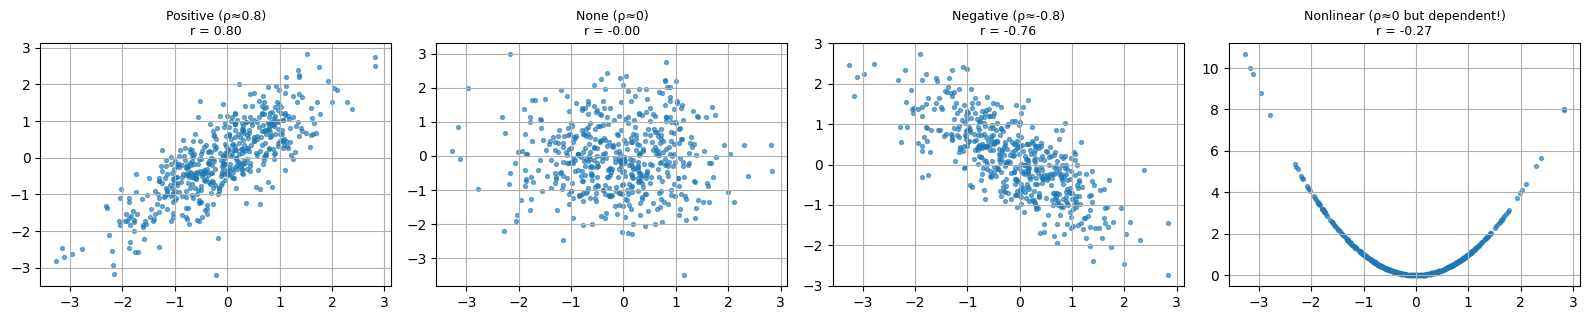

In [33]:
# Simulated correlations
n = 500
x = rng.normal(0, 1, n)
cases = {
    "Positive (ρ≈0.8)": 0.8 * x + 0.6 * rng.normal(0, 1, n),
    "None (ρ≈0)":       rng.normal(0, 1, n),
    "Negative (ρ≈-0.8)": -0.8 * x + 0.6 * rng.normal(0, 1, n),
    "Nonlinear (ρ≈0 but dependent!)": x ** 2,
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
for ax, (title, y) in zip(axes, cases.items()):
    ax.scatter(x, y, s=8, alpha=0.6)
    ax.set_title(f"{title}\nr = {np.corrcoef(x, y)[0,1]:.2f}", fontsize=9)
plt.tight_layout(); plt.show()

## 17. Cheat-Sheet & Practice

### Key formulas
| Concept | Formula |
|---|---|
| Classical probability | P(A) = favourable / total |
| Complement | P(Aᶜ) = 1 − P(A) |
| Addition | P(A∪B) = P(A) + P(B) − P(A∩B) |
| Conditional | P(A\|B) = P(A∩B) / P(B) |
| Multiplication | P(A∩B) = P(A)P(B\|A) |
| Independence | P(A∩B) = P(A)P(B) |
| Total probability | P(A) = ΣP(A\|Bᵢ)P(Bᵢ) |
| Bayes | P(B\|A) = P(A\|B)P(B) / P(A) |
| Expected value | E[X] = Σ x·p(x) |
| Variance | Var(X) = E[X²] − (E[X])² |

### Distribution summary
| Distribution | Models | Mean | Variance | scipy |
|---|---|---|---|---|
| Bernoulli(p) | one yes/no trial | p | p(1−p) | `stats.bernoulli` |
| Binomial(n,p) | # successes in n trials | np | np(1−p) | `stats.binom` |
| Geometric(p) | trials to 1st success | 1/p | (1−p)/p² | `stats.geom` |
| Poisson(λ) | # events in interval | λ | λ | `stats.poisson` |
| Uniform(a,b) | equally likely on [a,b] | (a+b)/2 | (b−a)²/12 | `stats.uniform` |
| Exponential(λ) | waiting time | 1/λ | 1/λ² | `stats.expon` |
| Normal(μ,σ²) | bell-shaped data, sums/means | μ | σ² | `stats.norm` |

### scipy method cheat-sheet
* `.pmf(k)` / `.pdf(x)`: probability mass / density at a point
* `.cdf(x)`: P(X ≤ x)
* `.sf(x)`: P(X > x) = 1 − cdf
* `.ppf(q)`: inverse CDF (quantile / percentile)
* `.rvs(size)`: random samples
* `.mean()`, `.var()`, `.std()`

### Why this matters for statistics
* **Sampling distributions** (via CLT) → confidence intervals & hypothesis tests.
* **Normal & z-scores** → standardising data and finding p-values.
* **Binomial/Poisson** → modelling counts and proportions.
* **Bayes** → updating beliefs; the basis of Bayesian statistics and classification (e.g., Naive Bayes).
* **Expected value & variance** → describing populations and estimator quality.

### Practice problems
1. Two cards are drawn without replacement from a deck. Find P(both are hearts). Verify with a simulation.
2. A test is 95% sensitive and 90% specific, and the disease prevalence is 2%. Find P(disease | positive).
3. A basketball player makes 70% of free throws. What is P(exactly 7 of 10)? P(at least 8 of 10)?
4. A website gets on average 3 visitors per minute. What is P(no visitors in a minute)? P(more than 5)?
5. Heights are ~ N(170, 8²) cm. What proportion are taller than 185? What height is the 95th percentile?
6. Simulate the CLT with a **uniform** population: plot the distribution of means for n = 1, 2, 5, 30.
7. Show by simulation that Var(X + Y) = Var(X) + Var(Y) + 2 Cov(X, Y) for correlated X and Y.